In [1]:
import os
import sys
from pathlib import Path

library_path = os.path.abspath('../../src')
if library_path not in sys.path:
    sys.path.append(library_path)
library_path = Path(library_path)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.calibration import calibration_curve

DATA_PATH = library_path.parent / "data"
PLOTS_PATH = library_path.parent / "plots"
PLOTS_PATH.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

In [3]:
from euroqol.utils import fit_classifiers, compute_weights, run_calibration_diagnostics, compute_smd

In [4]:
df = pd.read_csv(DATA_PATH / "wrangled_data.csv", low_memory=False)

hse2022   = df[df["dataset"] == "HSE 2022"].copy()
daphnie_24 = df[df["dataset"] == "DAPHNIE 2024"].copy()

print(f"HSE 2022: n = {len(hse2022):,}")
print(f"DAPHNIE 2024:  n = {len(daphnie_24):,}")
print(f"Class ratio    DAPHNIE:HSE = 1:{len(hse2022)/len(daphnie_24):.1f}")

HSE 2022: n = 7,590
DAPHNIE 2024:  n = 5,237
Class ratio    DAPHNIE:HSE = 1:1.4


In [5]:
# 17-variable predictor set for the restricted pipeline.
# Extends the 13-variable notebook 03 set with resp, skin, paVig, paMod.
EXTRA_FEATURES = [
    "paVig", "paMod", "resp", "skin",
]
BASE_FEATURES = [
    "Sex", "age7cat", "eth2cat", "emp_cat_Employed", "emp_cat_Other (Sick/Home/etc)", "emp_cat_Retired",
    "emp_cat_Student", "emp_cat_Unemployed", "edu_cat_2", "smoke_ecig", "diabetes",
    "meds_num", "ill_dis"
]
ALL_FEATURES = BASE_FEATURES + EXTRA_FEATURES
ALL_FEATURES = [f for f in ALL_FEATURES if f in df.columns]
print(f"Features ({len(ALL_FEATURES)}):")
print(ALL_FEATURES)

Features (17):
['Sex', 'age7cat', 'eth2cat', 'emp_cat_Employed', 'emp_cat_Other (Sick/Home/etc)', 'emp_cat_Retired', 'emp_cat_Student', 'emp_cat_Unemployed', 'edu_cat_2', 'smoke_ecig', 'diabetes', 'meds_num', 'ill_dis', 'paVig', 'paMod', 'resp', 'skin']


In [6]:
MODEL_COLORS = {
    "LR":               "#d62728",
    "LR + Platt":       "#ff7f0e",
    "LR + Venn-Abers":  "#e377c2",
    "HGB":              "#1f77b4",
    "HGB + Isotonic":   "#17becf",
    "HGB + Venn-Abers": "#2ca02c",
}

n_src, n_tgt = len(daphnie_24), len(hse2022)
print(f"DAPHNIE 2024 (n={n_src:,}) vs HSE 2022 (n={n_tgt:,})")
print(f"Class ratio DAPHNIE:HSE = 1:{n_tgt/n_src:.1f}")

models, auc_lr, auc_hgb, X, y = fit_classifiers(daphnie_24, hse2022, ALL_FEATURES)

print(f"\nBase model AUC (5-fold CV):")
print(f"  LR  : {auc_lr.mean():.3f}  (± {auc_lr.std():.3f})")
print(f"  HGB : {auc_hgb.mean():.3f}  (± {auc_hgb.std():.3f})")

X_daphnie = daphnie_24[ALL_FEATURES]
weights = {}
print(f"\nImportance weight diagnostics (99th-pct clip):")
print(f"  {'Model':<25}  {'clip':>6}  {'n_clip':>8}  {'ESS':>14}")
for name, clf in models.items():
    w, clip_val, n_clip, n_eff = compute_weights(clf, X_daphnie)
    weights[name] = w
    print(f"  {name:<25}  {clip_val:>6.2f}  {n_clip:>5} ({100*n_clip/n_src:.1f}%)  "
          f"{n_eff:>6.0f}/{n_src} ({100*n_eff/n_src:.1f}%)")

DAPHNIE 2024 (n=5,237) vs HSE 2022 (n=7,590)
Class ratio DAPHNIE:HSE = 1:1.4

Base model AUC (5-fold CV):
  LR  : 0.757  (± 0.007)
  HGB : 0.903  (± 0.007)

Importance weight diagnostics (99th-pct clip):
  Model                        clip    n_clip             ESS
  LR                           6.40     53 (1.0%)    2483/5237 (47.4%)
  LR + Platt                   5.44     53 (1.0%)    2825/5237 (53.9%)
  LR + Venn-Abers              6.72     45 (0.9%)    2193/5237 (41.9%)
  HGB                         10.74     53 (1.0%)    1064/5237 (20.3%)
  HGB + Isotonic              10.21     53 (1.0%)    1178/5237 (22.5%)
  HGB + Venn-Abers            12.05     52 (1.0%)    1057/5237 (20.2%)


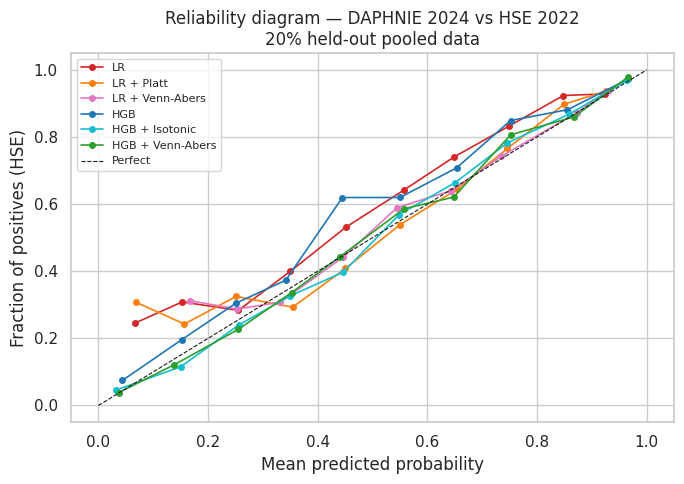


Calibration metrics (held-out 20%):


,Brier score,ECE
Model,,
LR,0.202,0.079
LR + Platt,0.197,0.035
LR + Venn-Abers,0.196,0.014
HGB,0.128,0.042
HGB + Isotonic,0.125,0.018
HGB + Venn-Abers,0.126,0.016


In [7]:
probs, y_cal, cal_metrics = run_calibration_diagnostics(daphnie_24, hse2022, ALL_FEATURES)

fig, ax = plt.subplots(figsize=(7, 5))
for name, p in probs.items():
    frac, mean_pred = calibration_curve(y_cal, p, n_bins=10, strategy="uniform")
    ax.plot(mean_pred, frac, marker="o", markersize=4, linewidth=1.2,
            label=name, color=MODEL_COLORS[name])
ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Perfect")
ax.set_title("Reliability diagram — DAPHNIE 2024 vs HSE 2022\n20% held-out pooled data")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives (HSE)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(PLOTS_PATH / "calibration_reliability_DAPHNIE24_vs_HSE22_all_features.png", dpi=600, bbox_inches="tight")
plt.show()

print("\nCalibration metrics (held-out 20%):")
display(cal_metrics.round(4))

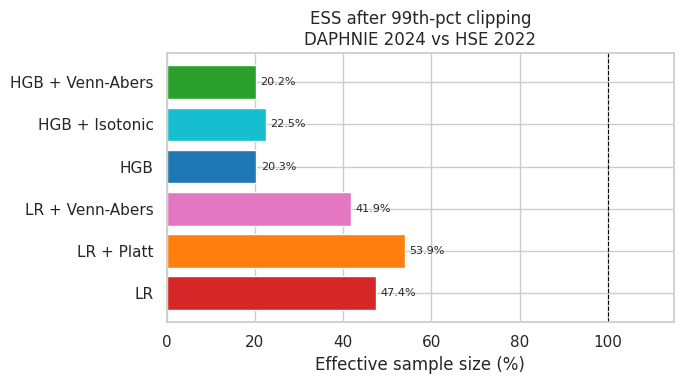

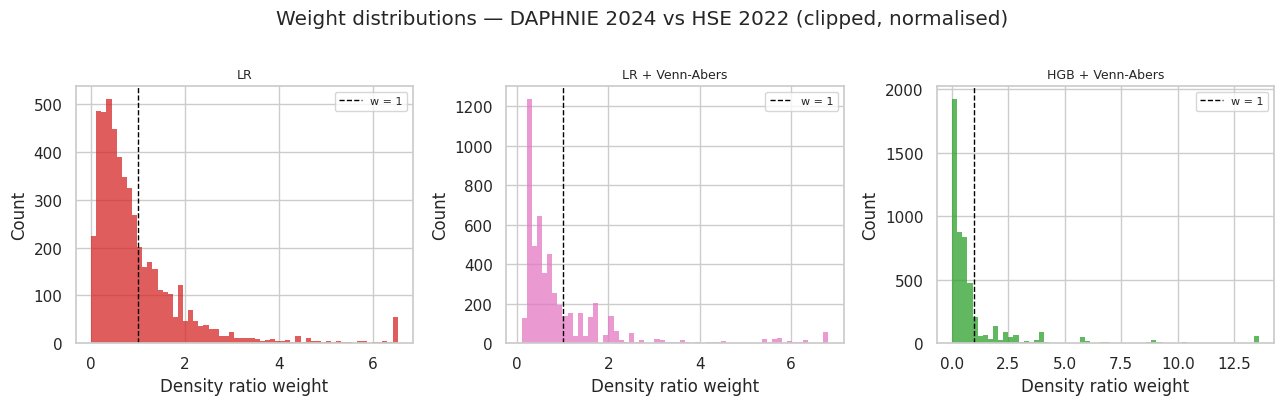

In [8]:
# ESS comparison across all six models
names    = list(weights.keys())
ess_pct  = [weights[n].sum()**2 / (weights[n]**2).sum() / n_src * 100 for n in names]

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(names, ess_pct, color=[MODEL_COLORS[n] for n in names])
ax.axvline(100, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Effective sample size (%)")
ax.set_title("ESS after 99th-pct clipping\nDAPHNIE 2024 vs HSE 2022")
ax.set_xlim(0, 115)
for i, v in enumerate(ess_pct):
    ax.text(v + 1, i, f"{v:.1f}%", va="center", fontsize=8)
plt.tight_layout()
plt.savefig(PLOTS_PATH / "ess_comparison_DAPHNIE24_vs_HSE22_all_features.png", dpi=600, bbox_inches="tight")
plt.show()

# Weight distributions — LR, LR+VA, HGB+VA
KEY_DIST = ["LR", "LR + Venn-Abers", "HGB + Venn-Abers"]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, name in zip(axes, KEY_DIST):
    w = weights[name]
    ax.hist(w, bins=60, color=MODEL_COLORS[name], edgecolor="none", alpha=0.75)
    ax.axvline(1.0, color="black", linewidth=1.0, linestyle="--", label="w = 1")
    ax.set_title(name, fontsize=9)
    ax.set_xlabel("Density ratio weight")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)

fig.suptitle("Weight distributions — DAPHNIE 2024 vs HSE 2022 (clipped, normalised)", y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_PATH / "density_ratio_weight_distributions_DAPHNIE24_vs_HSE22_all_features.png", dpi=600, bbox_inches="tight")
plt.show()

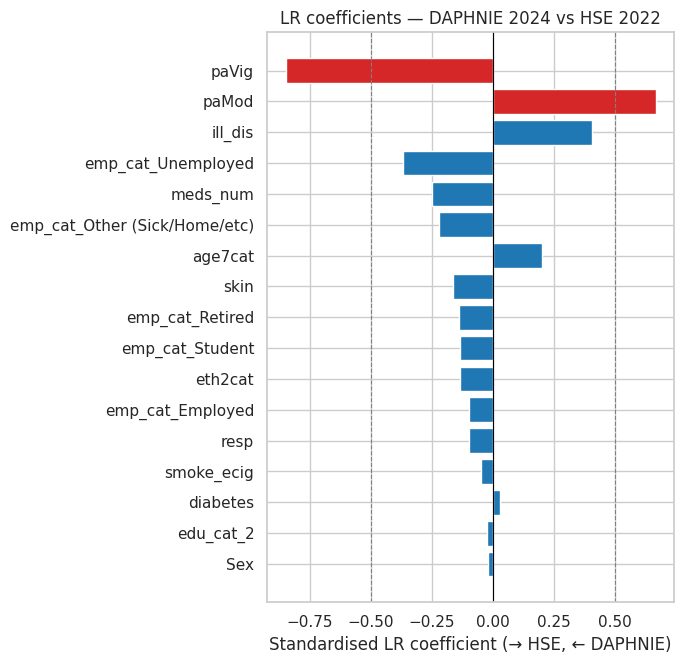

LR coefficients (standardised):


,coefficient,|coefficient|
paVig,-0.847,0.847
paMod,0.667,0.667
ill_dis,0.405,0.405
emp_cat_Unemployed,-0.368,0.368
meds_num,-0.247,0.247
emp_cat_Other (Sick/Home/etc),-0.222,0.222
age7cat,0.200,0.200
skin,-0.162,0.162
emp_cat_Retired,-0.139,0.139
emp_cat_Student,-0.136,0.136


In [9]:
# LR coefficient inspection
# Use X.columns (features the model was actually fitted on) rather than FEATURES,
# so this cell is safe to run even if FEATURES was redefined after fitting.
clf       = models["LR"].named_steps["clf"]
fit_feats = X.columns.tolist()
coef      = pd.Series(clf.coef_[0], index=fit_feats).sort_values(key=abs)
colors    = ["#d62728" if abs(v) > 0.5 else "#1f77b4" for v in coef]

fig, ax = plt.subplots(figsize=(7, max(5, len(fit_feats) * 0.4)))
ax.barh(coef.index, coef.values, color=colors)
ax.axvline(0,    color="black", linewidth=0.8)
ax.axvline( 0.5, color="grey",  linewidth=0.8, linestyle="--")
ax.axvline(-0.5, color="grey",  linewidth=0.8, linestyle="--")
ax.set_xlabel("Standardised LR coefficient (→ HSE, ← DAPHNIE)")
ax.set_title("LR coefficients — DAPHNIE 2024 vs HSE 2022")
plt.tight_layout()
plt.savefig(PLOTS_PATH / "lr_coefficients_DAPHNIE24_vs_HSE22_all_features.png", dpi=600, bbox_inches="tight")
plt.show()

tbl = (
    pd.DataFrame({
        "coefficient":   clf.coef_[0],
        "|coefficient|": np.abs(clf.coef_[0]),
    }, index=fit_feats)
    .sort_values("|coefficient|", ascending=False)
)
print("LR coefficients (standardised):")
display(tbl.round(3))

In [10]:
BALANCE_VARS = ALL_FEATURES
KEY_BALANCE  = ["LR", "LR + Venn-Abers", "HGB", "HGB + Venn-Abers"]

hse_wt = hse2022["wt_int"].fillna(1.0)
svy_wt = daphnie_24["svy_wt"].fillna(1.0)

smds = {}
for col in BALANCE_VARS:
    row = {"Before": compute_smd(daphnie_24[col], svy_wt, hse2022[col], hse_wt)}
    for name in KEY_BALANCE:
        w = weights[name]
        row[f"After: {name}"] = compute_smd(daphnie_24[col], svy_wt * w, hse2022[col], hse_wt)
    smds[col] = row

balance = pd.DataFrame(smds).T

print("Covariate balance (SMD) — DAPHNIE 2024 vs HSE 2022:")
display(
    balance.dropna(how="all")
    .sort_values("Before", key=abs, ascending=False)
    .round(3)
)

Covariate balance (SMD) — DAPHNIE 2024 vs HSE 2022:


,Before,After: LR,After: LR + Venn-Abers,After: HGB,After: HGB + Venn-Abers
paVig,0.400,-0.069,-0.081,-0.039,-0.034
paMod,-0.280,-0.071,-0.048,-0.144,-0.181
emp_cat_Unemployed,0.278,0.006,0.039,0.027,0.067
eth2cat,0.183,-0.094,-0.107,-0.150,-0.155
ill_dis,-0.146,0.122,0.154,0.172,0.193
emp_cat_Employed,-0.135,-0.113,-0.135,-0.208,-0.244
skin,0.119,-0.011,-0.009,0.009,0.002
age7cat,-0.111,0.203,0.216,0.373,0.386
emp_cat_Student,0.108,-0.047,-0.041,-0.164,-0.125
resp,0.077,-0.001,-0.009,0.069,0.064


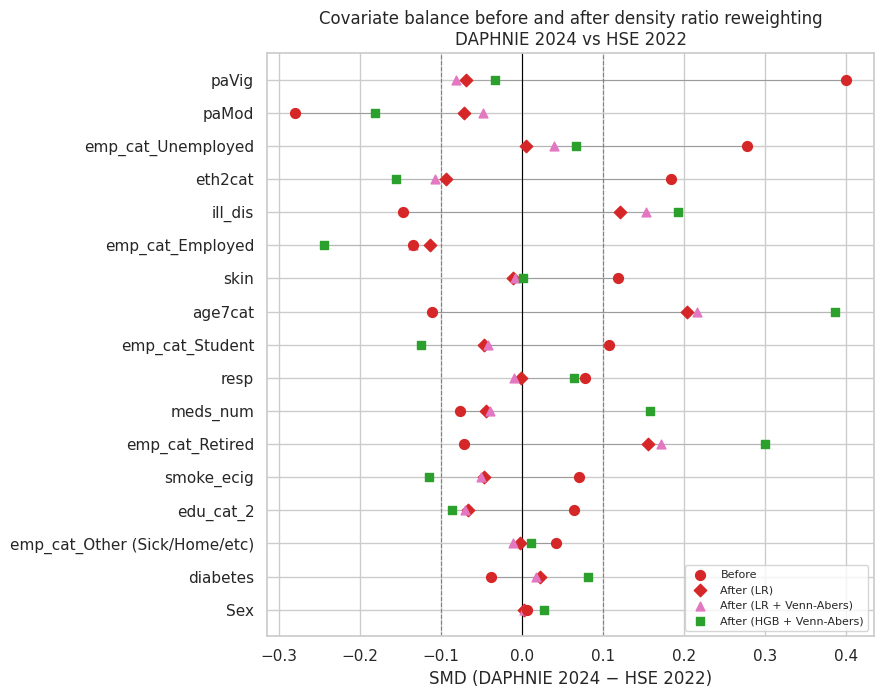

Balance on model features (17 variables):
  Before:              9 variables |SMD| > 0.1
  After (LR                    ): 4 variables |SMD| > 0.1
  After (LR + Venn-Abers       ): 5 variables |SMD| > 0.1
  After (HGB + Venn-Abers      ): 9 variables |SMD| > 0.1


In [11]:
# Love plot — Before vs LR, LR+VA, HGB+VA
KEY_LOVE     = ["LR", "LR + Venn-Abers", "HGB + Venn-Abers"]
LOVE_MARKERS = {"LR": "D", "LR + Venn-Abers": "^", "HGB + Venn-Abers": "s"}

tbl_plot = balance.dropna(subset=["Before"]).copy()
order    = tbl_plot["Before"].abs().sort_values().index
y_pos    = np.arange(len(order))
before   = tbl_plot.loc[order, "Before"]

fig, ax = plt.subplots(figsize=(9, max(6, len(order) * 0.42)))
ax.scatter(before, y_pos, color="#d62728", zorder=4, s=50, label="Before")

for name in KEY_LOVE:
    col   = f"After: {name}"
    after = tbl_plot.loc[order, col]
    ax.scatter(after, y_pos, color=MODEL_COLORS[name], zorder=3, s=40,
               marker=LOVE_MARKERS[name], label=f"After ({name})")
    for i, (b, a) in enumerate(zip(before, after)):
        ax.plot([b, a], [i, i], color="grey", linewidth=0.5, zorder=2, alpha=0.4)

ax.axvline(0,    color="black", linewidth=0.8)
ax.axvline( 0.1, color="grey",  linewidth=0.8, linestyle="--")
ax.axvline(-0.1, color="grey",  linewidth=0.8, linestyle="--")
ax.set_yticks(y_pos)
ax.set_yticklabels(order)
ax.set_xlabel("SMD (DAPHNIE 2024 − HSE 2022)")
ax.set_title("Covariate balance before and after density ratio reweighting\nDAPHNIE 2024 vs HSE 2022")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(PLOTS_PATH / "balance_pre_post_reweighting_DAPHNIE24_vs_HSE22_all_features.png", dpi=600, bbox_inches="tight")
plt.show()

# Summary
model_vars = [c for c in balance.index if c != "alcohol_yr"]
print(f"Balance on model features ({len(model_vars)} variables):")
print(f"  Before:              {balance.loc[model_vars, 'Before'].abs().gt(0.1).sum()} variables |SMD| > 0.1")
for name in KEY_LOVE:
    col = f"After: {name}"
    print(f"  After ({name:<22}): {balance.loc[model_vars, col].abs().gt(0.1).sum()} variables |SMD| > 0.1")
if "alcohol_yr" in balance.index:
    print(f"\nalcohol_yr (diagnostic only, not in model):")
    for col in ["Before"] + [f"After: {n}" for n in KEY_LOVE]:
        print(f"  {col:<35}: SMD = {balance.loc['alcohol_yr', col]:.3f}")

In [12]:
MODEL_COLORS = {
    "LR":               "#d62728",
    "LR + Platt":       "#ff7f0e",
    "LR + Venn-Abers":  "#e377c2",
    "HGB":              "#1f77b4",
    "HGB + Isotonic":   "#17becf",
    "HGB + Venn-Abers": "#2ca02c",
}

n_src, n_tgt = len(daphnie_24), len(hse2022)
print(f"DAPHNIE 2024 (n={n_src:,}) vs HSE 2022 (n={n_tgt:,})")
print(f"Class ratio DAPHNIE:HSE = 1:{n_tgt/n_src:.1f}")

models, auc_lr, auc_hgb, X, y = fit_classifiers(daphnie_24, hse2022, BASE_FEATURES)

print(f"\nBase model AUC (5-fold CV):")
print(f"  LR  : {auc_lr.mean():.3f}  (± {auc_lr.std():.3f})")
print(f"  HGB : {auc_hgb.mean():.3f}  (± {auc_hgb.std():.3f})")

X_daphnie = daphnie_24[BASE_FEATURES]
weights = {}
print(f"\nImportance weight diagnostics (99th-pct clip):")
print(f"  {'Model':<25}  {'clip':>6}  {'n_clip':>8}  {'ESS':>14}")
for name, clf in models.items():
    w, clip_val, n_clip, n_eff = compute_weights(clf, X_daphnie)
    weights[name] = w
    print(f"  {name:<25}  {clip_val:>6.2f}  {n_clip:>5} ({100*n_clip/n_src:.1f}%)  "
          f"{n_eff:>6.0f}/{n_src} ({100*n_eff/n_src:.1f}%)")

DAPHNIE 2024 (n=5,237) vs HSE 2022 (n=7,590)
Class ratio DAPHNIE:HSE = 1:1.4

Base model AUC (5-fold CV):
  LR  : 0.656  (± 0.004)
  HGB : 0.855  (± 0.008)

Importance weight diagnostics (99th-pct clip):
  Model                        clip    n_clip             ESS
  LR                           2.94     49 (0.9%)    3996/5237 (76.3%)
  LR + Platt                   2.47     53 (1.0%)    4323/5237 (82.6%)
  LR + Venn-Abers              4.10     43 (0.8%)    3571/5237 (68.2%)
  HGB                         14.44     53 (1.0%)    1045/5237 (19.9%)
  HGB + Isotonic              11.77     53 (1.0%)    1409/5237 (26.9%)
  HGB + Venn-Abers            12.27     51 (1.0%)    1314/5237 (25.1%)


/home/luisggon/.cache/pypoetry/virtualenvs/euroqol-1goflkTH-py3.12/lib/python3.12/site-packages/venn_abers/venn_abers.py:111: RuntimeWarning: All-NaN slice encountered
  if np.sum(np.isnan(np.nanmin(grads))) == 0:


/home/luisggon/.cache/pypoetry/virtualenvs/euroqol-1goflkTH-py3.12/lib/python3.12/site-packages/venn_abers/venn_abers.py:111: RuntimeWarning: All-NaN slice encountered
  if np.sum(np.isnan(np.nanmin(grads))) == 0:


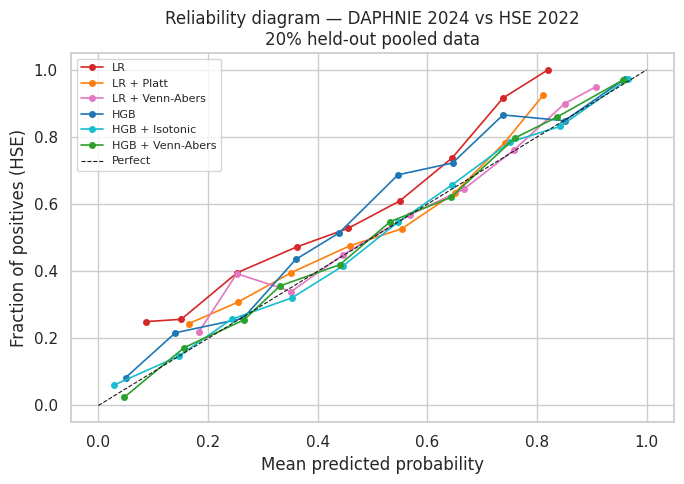


Calibration metrics (held-out 20%):


,Brier score,ECE
Model,,
LR,0.229,0.091
LR + Platt,0.222,0.031
LR + Venn-Abers,0.221,0.012
HGB,0.153,0.052
HGB + Isotonic,0.155,0.016
HGB + Venn-Abers,0.155,0.019


In [13]:
probs, y_cal, cal_metrics = run_calibration_diagnostics(daphnie_24, hse2022, BASE_FEATURES)

fig, ax = plt.subplots(figsize=(7, 5))
for name, p in probs.items():
    frac, mean_pred = calibration_curve(y_cal, p, n_bins=10, strategy="uniform")
    ax.plot(mean_pred, frac, marker="o", markersize=4, linewidth=1.2,
            label=name, color=MODEL_COLORS[name])
ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Perfect")
ax.set_title("Reliability diagram — DAPHNIE 2024 vs HSE 2022\n20% held-out pooled data")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives (HSE)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(PLOTS_PATH / "calibration_reliability_DAPHNIE24_vs_HSE22_all_features_base_features.png", dpi=600, bbox_inches="tight")
plt.show()

print("\nCalibration metrics (held-out 20%):")
display(cal_metrics.round(4))

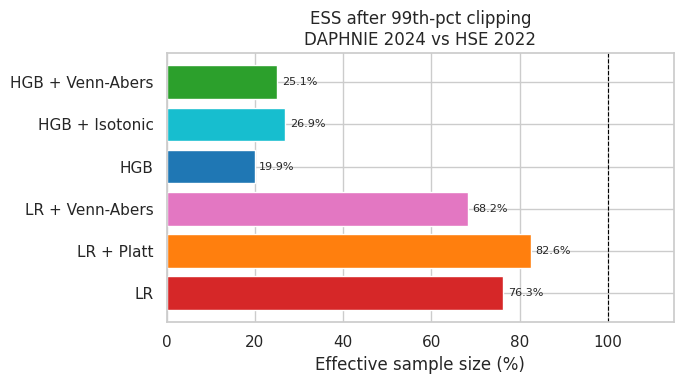

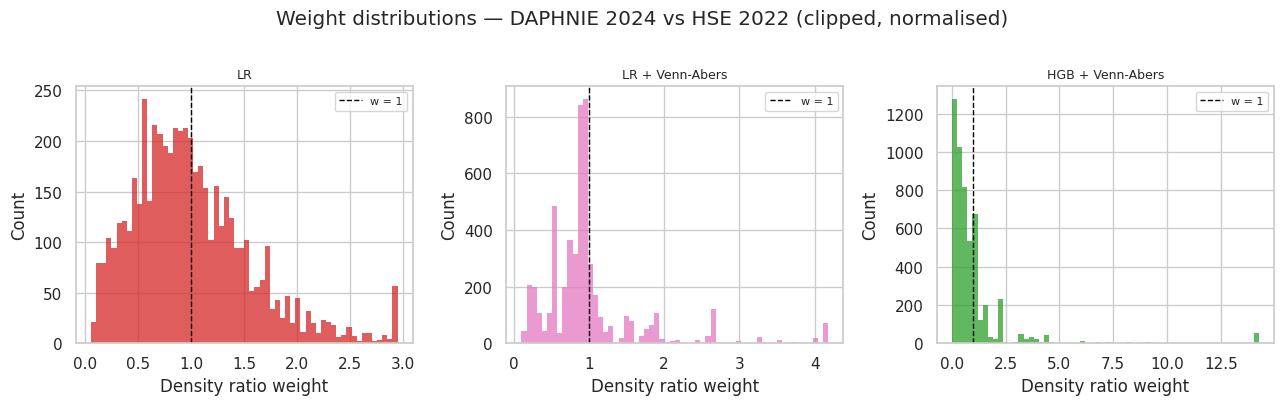

In [14]:
# ESS comparison across all six models
names    = list(weights.keys())
ess_pct  = [weights[n].sum()**2 / (weights[n]**2).sum() / n_src * 100 for n in names]

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(names, ess_pct, color=[MODEL_COLORS[n] for n in names])
ax.axvline(100, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Effective sample size (%)")
ax.set_title("ESS after 99th-pct clipping\nDAPHNIE 2024 vs HSE 2022")
ax.set_xlim(0, 115)
for i, v in enumerate(ess_pct):
    ax.text(v + 1, i, f"{v:.1f}%", va="center", fontsize=8)
plt.tight_layout()
plt.savefig(PLOTS_PATH / "ess_comparison_DAPHNIE24_vs_HSE22_base_features.png", dpi=600, bbox_inches="tight")
plt.show()

# Weight distributions — LR, LR+VA, HGB+VA
KEY_DIST = ["LR", "LR + Venn-Abers", "HGB + Venn-Abers"]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, name in zip(axes, KEY_DIST):
    w = weights[name]
    ax.hist(w, bins=60, color=MODEL_COLORS[name], edgecolor="none", alpha=0.75)
    ax.axvline(1.0, color="black", linewidth=1.0, linestyle="--", label="w = 1")
    ax.set_title(name, fontsize=9)
    ax.set_xlabel("Density ratio weight")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)

fig.suptitle("Weight distributions — DAPHNIE 2024 vs HSE 2022 (clipped, normalised)", y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_PATH / "density_ratio_weight_distributions_DAPHNIE24_vs_HSE22_base_features.png", dpi=600, bbox_inches="tight")
plt.show()

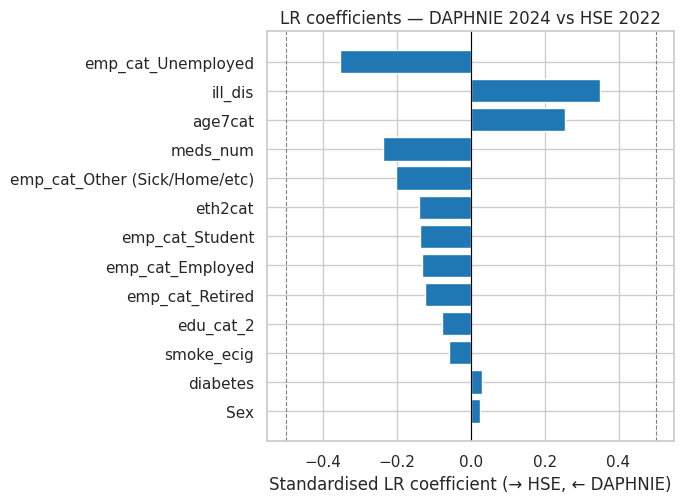

LR coefficients (standardised):


,coefficient,|coefficient|
emp_cat_Unemployed,-0.355,0.355
ill_dis,0.350,0.350
age7cat,0.256,0.256
meds_num,-0.236,0.236
emp_cat_Other (Sick/Home/etc),-0.202,0.202
eth2cat,-0.141,0.141
emp_cat_Student,-0.138,0.138
emp_cat_Employed,-0.131,0.131
emp_cat_Retired,-0.123,0.123
edu_cat_2,-0.077,0.077


In [15]:
# LR coefficient inspection
# Use X.columns (features the model was actually fitted on) rather than FEATURES,
# so this cell is safe to run even if FEATURES was redefined after fitting.
clf       = models["LR"].named_steps["clf"]
fit_feats = X.columns.tolist()
coef      = pd.Series(clf.coef_[0], index=fit_feats).sort_values(key=abs)
colors    = ["#d62728" if abs(v) > 0.5 else "#1f77b4" for v in coef]

fig, ax = plt.subplots(figsize=(7, max(5, len(fit_feats) * 0.4)))
ax.barh(coef.index, coef.values, color=colors)
ax.axvline(0,    color="black", linewidth=0.8)
ax.axvline( 0.5, color="grey",  linewidth=0.8, linestyle="--")
ax.axvline(-0.5, color="grey",  linewidth=0.8, linestyle="--")
ax.set_xlabel("Standardised LR coefficient (→ HSE, ← DAPHNIE)")
ax.set_title("LR coefficients — DAPHNIE 2024 vs HSE 2022")
plt.tight_layout()
plt.savefig(PLOTS_PATH / "lr_coefficients_DAPHNIE24_vs_HSE22_base_features.png", dpi=600, bbox_inches="tight")
plt.show()

tbl = (
    pd.DataFrame({
        "coefficient":   clf.coef_[0],
        "|coefficient|": np.abs(clf.coef_[0]),
    }, index=fit_feats)
    .sort_values("|coefficient|", ascending=False)
)
print("LR coefficients (standardised):")
display(tbl.round(3))

In [16]:
BALANCE_VARS = BASE_FEATURES
KEY_BALANCE  = ["LR", "LR + Venn-Abers", "HGB", "HGB + Venn-Abers"]

hse_wt = hse2022["wt_int"].fillna(1.0)
svy_wt = daphnie_24["svy_wt"].fillna(1.0)

smds = {}
for col in BALANCE_VARS:
    row = {"Before": compute_smd(daphnie_24[col], svy_wt, hse2022[col], hse_wt)}
    for name in KEY_BALANCE:
        w = weights[name]
        row[f"After: {name}"] = compute_smd(daphnie_24[col], svy_wt * w, hse2022[col], hse_wt)
    smds[col] = row

balance = pd.DataFrame(smds).T

print("Covariate balance (SMD) — DAPHNIE 2024 vs HSE 2022:")
display(
    balance.dropna(how="all")
    .sort_values("Before", key=abs, ascending=False)
    .round(3)
)

Covariate balance (SMD) — DAPHNIE 2024 vs HSE 2022:


,Before,After: LR,After: LR + Venn-Abers,After: HGB,After: HGB + Venn-Abers
emp_cat_Unemployed,0.278,-0.005,0.010,0.030,0.057
eth2cat,0.183,-0.103,-0.091,-0.119,-0.133
ill_dis,-0.146,0.109,0.168,0.205,0.191
emp_cat_Employed,-0.135,-0.111,-0.138,-0.221,-0.228
age7cat,-0.111,0.222,0.229,0.381,0.370
emp_cat_Student,0.108,-0.071,-0.066,-0.134,-0.137
meds_num,-0.077,-0.055,-0.049,0.111,0.132
emp_cat_Retired,-0.072,0.162,0.191,0.272,0.276
smoke_ecig,0.070,-0.030,-0.029,-0.098,-0.075
edu_cat_2,0.065,-0.069,-0.062,-0.057,-0.056


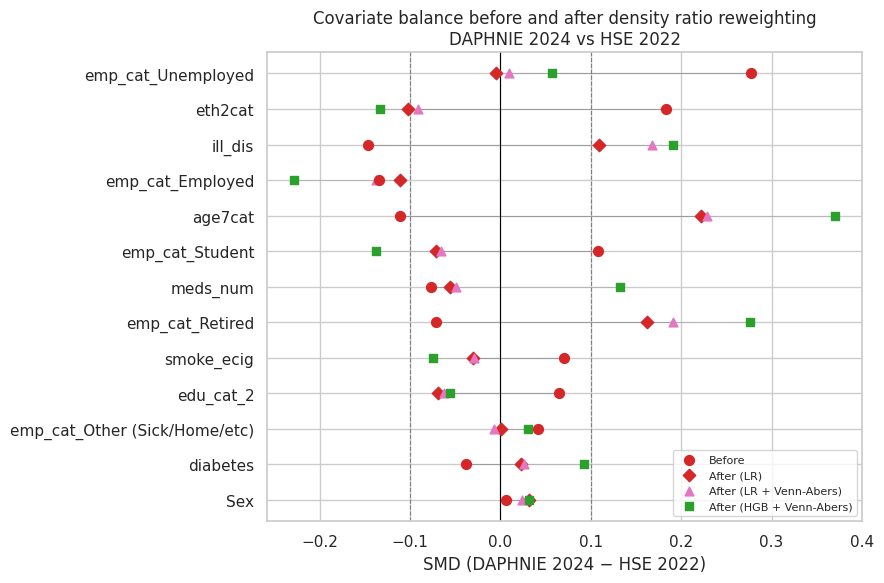

Balance on model features (13 variables):
  Before:              6 variables |SMD| > 0.1
  After (LR                    ): 5 variables |SMD| > 0.1
  After (LR + Venn-Abers       ): 4 variables |SMD| > 0.1
  After (HGB + Venn-Abers      ): 7 variables |SMD| > 0.1


In [17]:
# Love plot — Before vs LR, LR+VA, HGB+VA
KEY_LOVE     = ["LR", "LR + Venn-Abers", "HGB + Venn-Abers"]
LOVE_MARKERS = {"LR": "D", "LR + Venn-Abers": "^", "HGB + Venn-Abers": "s"}

tbl_plot = balance.dropna(subset=["Before"]).copy()
order    = tbl_plot["Before"].abs().sort_values().index
y_pos    = np.arange(len(order))
before   = tbl_plot.loc[order, "Before"]

fig, ax = plt.subplots(figsize=(9, max(6, len(order) * 0.42)))
ax.scatter(before, y_pos, color="#d62728", zorder=4, s=50, label="Before")

for name in KEY_LOVE:
    col   = f"After: {name}"
    after = tbl_plot.loc[order, col]
    ax.scatter(after, y_pos, color=MODEL_COLORS[name], zorder=3, s=40,
               marker=LOVE_MARKERS[name], label=f"After ({name})")
    for i, (b, a) in enumerate(zip(before, after)):
        ax.plot([b, a], [i, i], color="grey", linewidth=0.5, zorder=2, alpha=0.4)

ax.axvline(0,    color="black", linewidth=0.8)
ax.axvline( 0.1, color="grey",  linewidth=0.8, linestyle="--")
ax.axvline(-0.1, color="grey",  linewidth=0.8, linestyle="--")
ax.set_yticks(y_pos)
ax.set_yticklabels(order)
ax.set_xlabel("SMD (DAPHNIE 2024 − HSE 2022)")
ax.set_title("Covariate balance before and after density ratio reweighting\nDAPHNIE 2024 vs HSE 2022")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(PLOTS_PATH / "balance_pre_post_reweighting_DAPHNIE24_vs_HSE22_base_features.png", dpi=600, bbox_inches="tight")
plt.show()

# Summary
model_vars = [c for c in balance.index if c != "alcohol_yr"]
print(f"Balance on model features ({len(model_vars)} variables):")
print(f"  Before:              {balance.loc[model_vars, 'Before'].abs().gt(0.1).sum()} variables |SMD| > 0.1")
for name in KEY_LOVE:
    col = f"After: {name}"
    print(f"  After ({name:<22}): {balance.loc[model_vars, col].abs().gt(0.1).sum()} variables |SMD| > 0.1")
if "alcohol_yr" in balance.index:
    print(f"\nalcohol_yr (diagnostic only, not in model):")
    for col in ["Before"] + [f"After: {n}" for n in KEY_LOVE]:
        print(f"  {col:<35}: SMD = {balance.loc['alcohol_yr', col]:.3f}")